In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score


train = pd.read_csv("../1-Data/train_processed.csv")
x_train_before = train.drop(columns=["HeartDisease"])
y_train = train["HeartDisease"]

test = pd.read_csv("../1-Data/test_processed.csv")
x_test_before = test.drop(columns=["HeartDisease"])
y_test = test["HeartDisease"]


CHOSEN_C = 0.01
CHOSEN_THRESHOLD = 0.45

# =========================================================
# MODEL BEFORE FEATURE
# =========================================================
model_before = LogisticRegression(C=CHOSEN_C, random_state=42, max_iter=1000)
model_before.fit(x_train_before, y_train)

y_proba_before = model_before.predict_proba(x_test_before)[:, 1]
y_pred_before = (y_proba_before >= CHOSEN_THRESHOLD).astype(int)
acc_before = accuracy_score(y_test, y_pred_before)

# =========================================================
# MODEL AFTER LLM FEATURE ENGINEERING
# =========================================================
x_train_after = x_train_before.copy()
x_test_after = x_test_before.copy()

# Implement the Exercise Stress Index formula suggested by the LLM
# Formula: Oldpeak + (ExerciseAngina * ST_Slope_Up)
x_train_after["Exercise_Stress_Index"] = x_train_after["Oldpeak"] + (x_train_after["ExerciseAngina"] * x_train_after["ST_Slope_Up"])
x_test_after["Exercise_Stress_Index"] = x_test_after["Oldpeak"] + (x_test_after["ExerciseAngina"] * x_test_after["ST_Slope_Up"])

model_after = LogisticRegression(C=CHOSEN_C, random_state=42, max_iter=1000)
model_after.fit(x_train_after, y_train)

y_proba_after = model_after.predict_proba(x_test_after)[:, 1]
y_pred_after = (y_proba_after >= CHOSEN_THRESHOLD).astype(int)
acc_after = accuracy_score(y_test, y_pred_after)


print("\n=========================================================")
print("      CONTROLLED EXPERIMENT: EXERCISE STRESS INDEX       ")
print("=========================================================")
print(f"Accuracy BEFORE Feature: {acc_before * 100:.2f}%")
print(f"Accuracy AFTER Feature:  {acc_after * 100:.2f}%")
print(f"Net Absolute Impact:     {((acc_after - acc_before) * 100):+.2f}%")
print("=========================================================")

print("\nClassification Report BEFORE:")
print(classification_report(y_test, y_pred_before, target_names=["Normal", "Heart Disease"]))

print("\nClassification Report AFTER:")
print(classification_report(y_test, y_pred_after, target_names=["Normal", "Heart Disease"]))


      CONTROLLED EXPERIMENT: EXERCISE STRESS INDEX       
Accuracy BEFORE Feature: 88.59%
Accuracy AFTER Feature:  86.96%
Net Absolute Impact:     -1.63%

Classification Report BEFORE:
               precision    recall  f1-score   support

       Normal       0.91      0.83      0.87        82
Heart Disease       0.87      0.93      0.90       102

     accuracy                           0.89       184
    macro avg       0.89      0.88      0.88       184
 weighted avg       0.89      0.89      0.89       184


Classification Report AFTER:
               precision    recall  f1-score   support

       Normal       0.90      0.79      0.84        82
Heart Disease       0.85      0.93      0.89       102

     accuracy                           0.87       184
    macro avg       0.88      0.86      0.87       184
 weighted avg       0.87      0.87      0.87       184



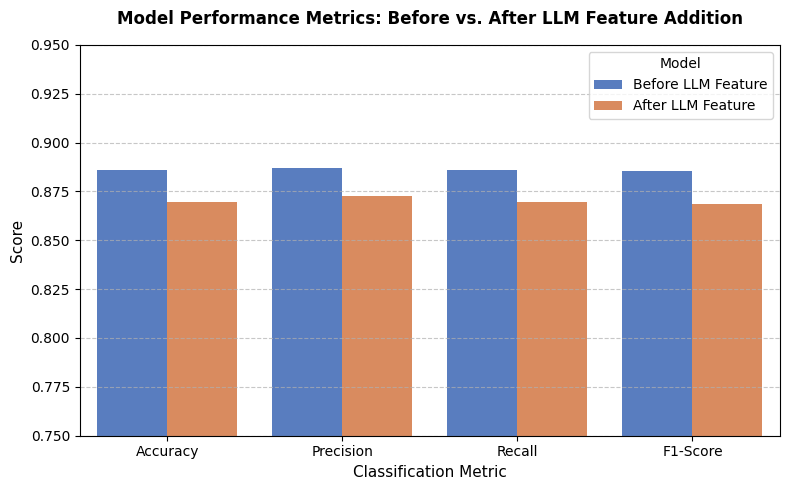

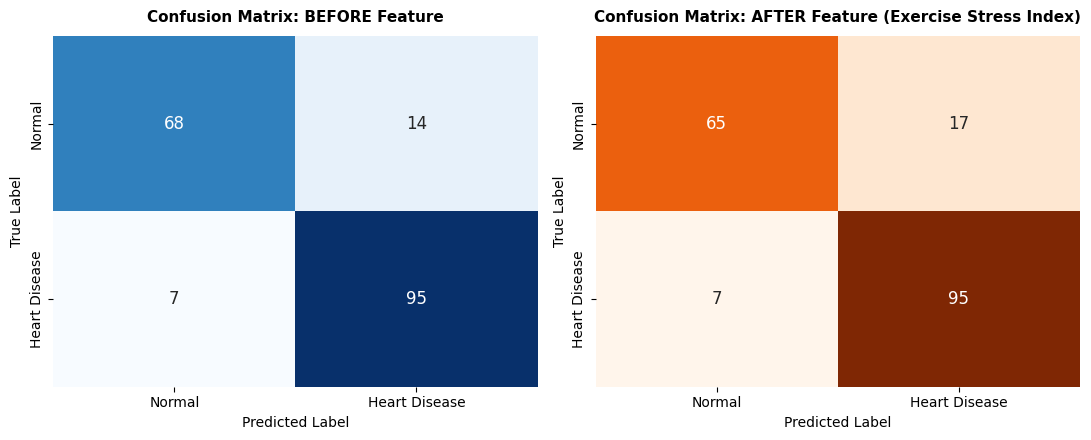

In [3]:
import seaborn as sns

# =========================================================
# CHART 1: COMPARATIVE OVERVIEW BAR CHART
# =========================================================
metrics_before = {
    'Accuracy': accuracy_score(y_test, y_pred_before),
    'Precision': precision_score(y_test, y_pred_before, average='weighted'),
    'Recall': recall_score(y_test, y_pred_before, average='weighted'),
    'F1-Score': f1_score(y_test, y_pred_before, average='weighted')
}

metrics_after = {
    'Accuracy': accuracy_score(y_test, y_pred_after),
    'Precision': precision_score(y_test, y_pred_after, average='weighted'),
    'Recall': recall_score(y_test, y_pred_after, average='weighted'),
    'F1-Score': f1_score(y_test, y_pred_after, average='weighted')
}

df_metrics = pd.DataFrame([metrics_before, metrics_after], index=['Before LLM Feature', 'After LLM Feature']).T
df_melted = df_metrics.reset_index().melt(id_vars='index', var_name='Model', value_name='Score')
df_melted.columns = ['Metric', 'Model', 'Score']

fig1, ax1 = plt.subplots(figsize=(8, 5))
sns.barplot(x='Metric', y='Score', hue='Model', data=df_melted, palette='muted', ax=ax1)
ax1.set_ylim(0.75, 0.95)
ax1.set_title('Model Performance Metrics: Before vs. After LLM Feature Addition', fontsize=12, fontweight='bold', pad=15)
ax1.set_ylabel('Score', fontsize=11)
ax1.set_xlabel('Classification Metric', fontsize=11)
ax1.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('performance_comparison.png', dpi=300)
plt.show()

# =========================================================
# CHART 2: SIDE-BY-SIDE CONFUSION MATRICES
# =========================================================
cm_before = confusion_matrix(y_test, y_pred_before)
cm_after = confusion_matrix(y_test, y_pred_after)

fig2, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Plot Before
sns.heatmap(cm_before, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Normal', 'Heart Disease'], yticklabels=['Normal', 'Heart Disease'], ax=axes[0], annot_kws={'size': 12})
axes[0].set_title('Confusion Matrix: BEFORE Feature', fontsize=11, fontweight='bold', pad=10)
axes[0].set_xlabel('Predicted Label', fontsize=10)
axes[0].set_ylabel('True Label', fontsize=10)

# Plot After
sns.heatmap(cm_after, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['Normal', 'Heart Disease'], yticklabels=['Normal', 'Heart Disease'], ax=axes[1], annot_kws={'size': 12})
axes[1].set_title('Confusion Matrix: AFTER Feature (Exercise Stress Index)', fontsize=11, fontweight='bold', pad=10)
axes[1].set_xlabel('Predicted Label', fontsize=10)
axes[1].set_ylabel('True Label', fontsize=10)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300)
plt.show()